# Problem Set: Neural Networks (Regression)

<span style="color:red">Note:</span> the intro-to-PyTorch lab and the Day 1
slides are your friends 

## Predicting House Prices with Feedforward Neural Networks

Unlike a classification task, here you'll **predict a continuous number**: the median
house value of a California district from 8 numeric features. This is a **regression**
problem, so you'll use **mean-squared-error loss** (`nn.MSELoss`) instead of
cross-entropy.

Everything else is the toolkit from lecture: tensors, fully-connected `nn.Module`
networks, the training loop, Adam/SGD, and regularization. Feedforward only.

## Part I - Data

### Question 1: Load data + exploratory analysis

The [California Housing](https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset)
dataset has 20,640 districts, each with 8 features (median income, house age, average
rooms, etc.) and a target: the median house value in units of $100,000.

The data is loaded for you below.

**Your tasks:**
- Plot a histogram of the target values, and a scatter plot of one strong predictor
  (median income, the first feature) against the target.
- Shuffle the data and make an 80 / 20 train / test split.

In [41]:
from sklearn.datasets import fetch_california_housing
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

data = fetch_california_housing()
feature_names = list(data.feature_names)
x_all = data.data.astype("float32")      # (20640, 8)
y_all = data.target.astype("float32")    # median house value, in $100k
print("features:", feature_names)
print("x:", x_all.shape, " y:", y_all.shape)

features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
x: (20640, 8)  y: (20640,)


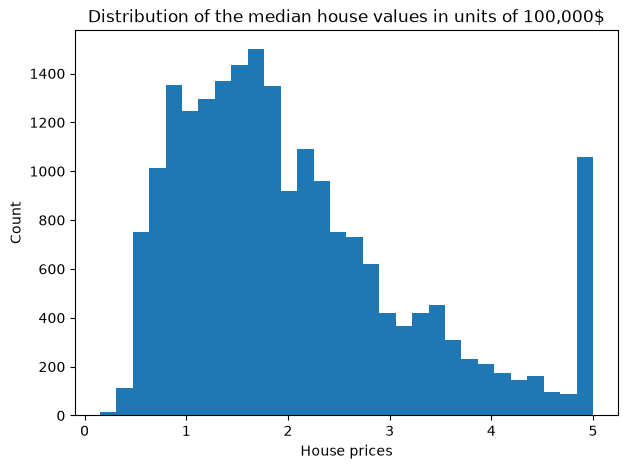

In [42]:
### YOUR CODE HERE
# Histogram showing the distribution of target value
plt.figure(figsize = (7, 5))
plt.hist(y_all, density = False, bins = 30)
plt.xlabel("House prices")
plt.ylabel("Count")
plt.title("Distribution of the median house values in units of 100,000$")
plt.show()

Text(0.5, 1.0, 'Scatterplot of the median income vs. median house value')

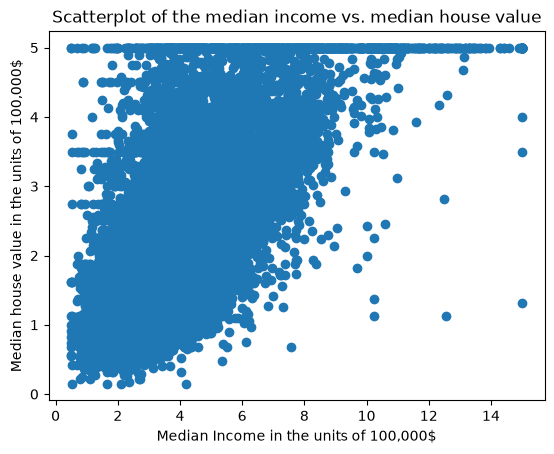

In [43]:
plt.scatter(x = x_all[:, 0], y = y_all)
plt.xlabel("Median Income in the units of 100,000$")
plt.ylabel("Median house value in the units of 100,000$")
plt.title("Scatterplot of the median income vs. median house value")

In [46]:
x_all_train, x_all_test, y_all_train, y_all_test = train_test_split(x_all, 
                                                                    y_all, 
                                                                    test_size = 0.2, 
                                                                    random_state = 42)

print(x_all_train.shape)
print(x_all_test.shape)
print(y_all_train.shape)
print(y_all_test.shape)

(16512, 8)
(4128, 8)
(16512,)
(4128,)


### Question 2: Prepare the data

- Convert the splits to tensors.
- **Standardize the features** using the **training** mean and standard deviation
  (subtract mean, divide by std), and apply the same transform to the test set.
- Wrap the training and test sets in `DataLoader`s (batch size 64; shuffle train).

**Short answer:** why is standardizing the features important for a neural network,
and why do we compute the mean/std from the training set only?

In [48]:
### YOUR CODE HERE
def standardize(tensor: torch.Tensor, mean: torch.Tensor = None, std: torch.Tensor = None):
    if mean == None and std == None:
        mean = torch.mean(tensor, axis = 0)
        std = torch.std(tensor, axis = 0)
        
    return (tensor - mean) / std, mean, std

In [50]:
x_all_train, y_all_train = torch.tensor(x_all_train), torch.tensor(y_all_train)
x_all_test, y_all_test = torch.tensor(x_all_test), torch.tensor(y_all_test)

# Standardize the training set and apply the same transformation for the test set
x_all_train_scaled, mean, std = standardize(x_all_train)
x_all_test_scaled, _, _ = standardize(x_all_test, mean, std)

train_dataset = TensorDataset(x_all_train_scaled, y_all_train)
test_dataset = TensorDataset(x_all_test_scaled, y_all_test)

train_dataloader = DataLoader(train_dataset, batch_size = 64, shuffle = True)
test_dataloader = DataLoader(test_dataset, batch_size = 64, shuffle = False)

/var/folders/k9/r49jp1111pb_ybyc2rrfy62c0000gn/T/ipykernel_67813/384471356.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_all_train, y_all_train = torch.tensor(x_all_train), torch.tensor(y_all_train)
/var/folders/k9/r49jp1111pb_ybyc2rrfy62c0000gn/T/ipykernel_67813/384471356.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_all_test, y_all_test = torch.tensor(x_all_test), torch.tensor(y_all_test)


## Part II - Neural Networks

### Question 3: Helper functions

Complete two helpers:

- `trainModel`: runs the training loop and returns the list of average epoch losses.
- `evaluate`: given a model and feature/target tensors, returns the **RMSE, MAE, and
  R^2** score.

**Note:** code the metrics **manually** (no scikit-learn). Reminders:
- RMSE = sqrt(mean((pred - y)^2))
- MAE  = mean(|pred - y|)
- R^2  = 1 - SS_res / SS_tot, where SS_res = sum((y - pred)^2) and
  SS_tot = sum((y - mean(y))^2)

In [116]:
def trainModel(model, n_epochs, optimizer, loss_fn, train_data_loader, test_data_loader):
    "train a regressor; return the list of average epoch losses"
    train_losses = []
    test_losses = []

    for epoch in range(n_epochs):
        model.train()
        train_loss = 0
        test_loss = 0
        
        for X, y in train_data_loader:
            y_pred = model(X).squeeze()

            loss = loss_fn(y_pred, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        model.eval()
        for X, y in test_data_loader:
            y_pred = model(X).squeeze()
            loss = loss_fn(y_pred, y)

            test_loss += loss.item()

        average_train_loss = train_loss / len(train_data_loader)
        print(f"Epoch {epoch + 1}: Train loss = {average_train_loss:.4f}")
        train_losses.append(average_train_loss)

        average_test_loss = test_loss / len(test_data_loader)
        print(f"Epoch {epoch + 1}: Test loss = {average_test_loss:.4f}")
        test_losses.append(average_test_loss)
            
    return train_losses, test_losses
        
        
def evaluate(model, x, y):
    "return rmse, mae, r2 (computed manually)"
    y_pred = model(x).squeeze() # (batch_size, )
    rmse = torch.sqrt(torch.mean((y_pred - y) ** 2))
    mae = torch.mean(torch.abs(y_pred - y))

    ss_res = torch.sum((y - y_pred) ** 2)
    ss_tot = torch.sum((y - torch.mean(y)) ** 2)

    r2 = 1 - ss_res / ss_tot

    return rmse, mae, r2

### Question 4: A single-hidden-layer regressor

Build and train a feedforward regressor.

**Architecture:** 8 features -> hidden layer of 64 (ReLU) -> 1 output (no activation
on the output - it's a real-valued prediction).

**Train:** MSE loss, Adam, batch size 64, at least 100 epochs.

Plot the training loss, report RMSE / MAE / R^2 on **train and test**, and make a
**predicted-vs-actual** scatter plot for the test set (a perfect model would lie on
the diagonal).

In [117]:
class RegressorFFN(nn.Module):
    def __init__(self):
        super().__init__()
        # YOUR CODE HERE
        self.layers = nn.Sequential(
            nn.Linear(in_features = 8, out_features = 64, bias = True),
            nn.ReLU(),
            nn.Linear(in_features = 64, out_features = 1, bias = True)
        )

    def forward(self, x):
        return self.layers(x)


In [120]:
model = RegressorFFN()
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(params = model.parameters())

train_losses, test_losses = trainModel(model, n_epochs = 100, optimizer = optimizer, loss_fn = loss_fn, 
                          train_data_loader = train_dataloader, test_data_loader = test_dataloader)

Epoch 1: Train loss = 1.9454
Epoch 1: Test loss = 0.7746
Epoch 2: Train loss = 0.6383
Epoch 2: Test loss = 0.5607
Epoch 3: Train loss = 0.4980
Epoch 3: Test loss = 0.4695
Epoch 4: Train loss = 0.4378
Epoch 4: Test loss = 0.4325
Epoch 5: Train loss = 0.4124
Epoch 5: Test loss = 0.4182
Epoch 6: Train loss = 0.3983
Epoch 6: Test loss = 0.4025
Epoch 7: Train loss = 0.3881
Epoch 7: Test loss = 0.3928
Epoch 8: Train loss = 0.3819
Epoch 8: Test loss = 0.3859
Epoch 9: Train loss = 0.3756
Epoch 9: Test loss = 0.3827
Epoch 10: Train loss = 0.3691
Epoch 10: Test loss = 0.3734
Epoch 11: Train loss = 0.3629
Epoch 11: Test loss = 0.3762
Epoch 12: Train loss = 0.3603
Epoch 12: Test loss = 0.3659
Epoch 13: Train loss = 0.3558
Epoch 13: Test loss = 0.3633
Epoch 14: Train loss = 0.3519
Epoch 14: Test loss = 0.3601
Epoch 15: Train loss = 0.3482
Epoch 15: Test loss = 0.3664
Epoch 16: Train loss = 0.3437
Epoch 16: Test loss = 0.3530
Epoch 17: Train loss = 0.3408
Epoch 17: Test loss = 0.3504
Epoch 18: Train

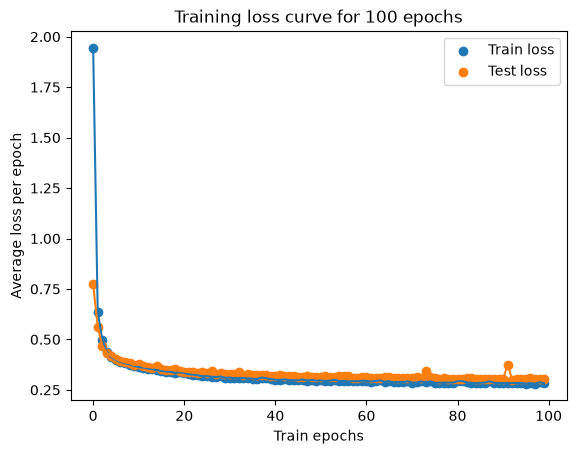

In [122]:
plt.scatter(x = np.arange(len(train_losses)), y = train_losses, label = "Train loss")
plt.scatter(x = np.arange(len(test_losses)), y = test_losses, label = "Test loss")
plt.plot(np.arange(len(train_losses)), train_losses)
plt.plot(np.arange(len(test_losses)), test_losses)

plt.xlabel("Train epochs")
plt.ylabel("Average loss per epoch")
plt.title("Training loss curve for 100 epochs")
plt.legend()

In [123]:
rmse_train, mae_train, r2_train = evaluate(model, x_all_train_scaled, y_all_train)
rmse_test, mae_test, r2_test = evaluate(model, x_all_test_scaled, y_all_test)

In [124]:
print(f"Train RMSE: {rmse_train} | Train MAE: {mae_train} | Train R2: {r2_train}")
print(f"Test RMSE: {rmse_test} | Test MAE: {mae_test} | Test R2: {r2_test}")

Train RMSE: 0.52662193775177 | Train MAE: 0.36478328704833984 | Train R2: 0.7925379872322083
Test RMSE: 0.5501955151557922 | Test MAE: 0.37651658058166504 | Test R2: 0.7689919471740723


/var/folders/k9/r49jp1111pb_ybyc2rrfy62c0000gn/T/ipykernel_67813/3210554091.py:7: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  perfect_line_dots = np.arange(y_all_test.min(), y_all_test.max() + 1)


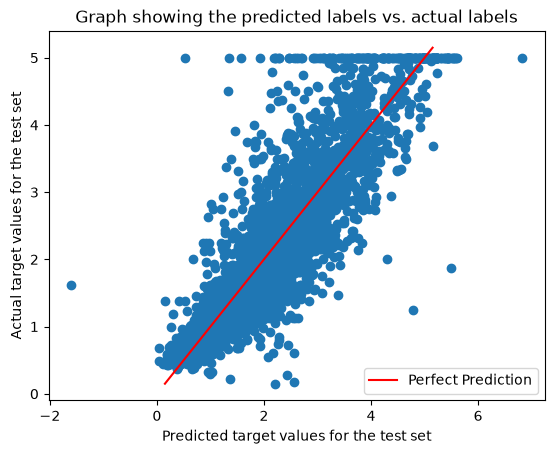

In [125]:
y_pred_test = model(x_all_test_scaled).squeeze()
plt.scatter(y_pred_test.detach().numpy(), y_all_test.detach().numpy())
plt.xlabel("Predicted target values for the test set")
plt.ylabel("Actual target values for the test set")
plt.title("Graph showing the predicted labels vs. actual labels")

perfect_line_dots = np.arange(y_all_test.min(), y_all_test.max() + 1)

plt.plot(perfect_line_dots, perfect_line_dots, c = "r", label = "Perfect Prediction")
plt.legend()

### Question 5: Your turn - build a better regressor

Design your own feedforward regressor aiming for a **test R^2 above 0.75**. Experiment
locally - no formal hyperparameter search needed. Knobs (all from lecture): number and
width of hidden layers, activation functions, dropout, learning rate, optimizer
(SGD vs Adam), weight decay, number of epochs.

Report RMSE / MAE / R^2 on train and test.

In [126]:
class BetterRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(8, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        return self.layers(x)

In [127]:
model = BetterRegressor()
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(params = model.parameters(), lr = 1e-3, weight_decay = 1e-4)
train_losses, test_losses = trainModel(model, n_epochs = 200, optimizer = optimizer, loss_fn = loss_fn, 
                          train_data_loader = train_dataloader, test_data_loader = test_dataloader)

Epoch 1: Train loss = 0.7733
Epoch 1: Test loss = 0.4257
Epoch 2: Train loss = 0.3930
Epoch 2: Test loss = 0.3782
Epoch 3: Train loss = 0.3578
Epoch 3: Test loss = 0.3467
Epoch 4: Train loss = 0.3382
Epoch 4: Test loss = 0.3408
Epoch 5: Train loss = 0.3229
Epoch 5: Test loss = 0.3257
Epoch 6: Train loss = 0.3124
Epoch 6: Test loss = 0.3229
Epoch 7: Train loss = 0.3034
Epoch 7: Test loss = 0.3137
Epoch 8: Train loss = 0.2960
Epoch 8: Test loss = 0.3625
Epoch 9: Train loss = 0.3656
Epoch 9: Test loss = 0.3076
Epoch 10: Train loss = 0.2964
Epoch 10: Test loss = 0.2977
Epoch 11: Train loss = 0.2845
Epoch 11: Test loss = 0.2913
Epoch 12: Train loss = 0.2856
Epoch 12: Test loss = 0.2965
Epoch 13: Train loss = 0.2812
Epoch 13: Test loss = 0.2873
Epoch 14: Train loss = 0.2784
Epoch 14: Test loss = 0.2927
Epoch 15: Train loss = 0.2745
Epoch 15: Test loss = 0.3117
Epoch 16: Train loss = 0.2772
Epoch 16: Test loss = 0.2924
Epoch 17: Train loss = 0.2744
Epoch 17: Test loss = 0.2794
Epoch 18: Train

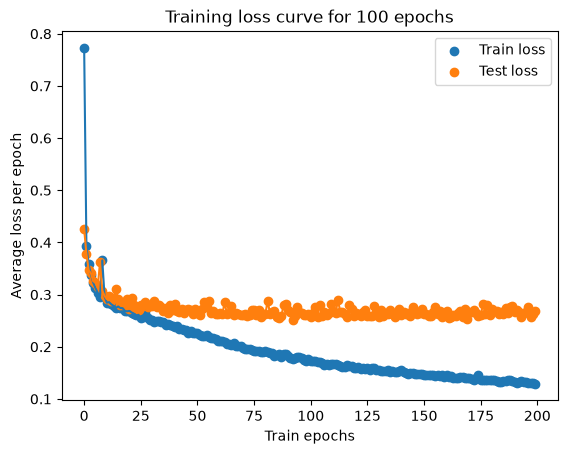

In [128]:
plt.scatter(x = np.arange(len(train_losses)), y = train_losses, label = "Train loss")
plt.scatter(x = np.arange(len(test_losses)), y = test_losses, label = "Test loss")
plt.plot(np.arange(len(train_losses)), train_losses)
plt.plot(np.arange(len(test_losses)), test_losses)

plt.xlabel("Train epochs")
plt.ylabel("Average loss per epoch")
plt.title("Training loss curve for 100 epochs")
plt.legend()

In [129]:
rmse_train, mae_train, r2_train = evaluate(model, x_all_train_scaled, y_all_train)
rmse_test, mae_test, r2_test = evaluate(model, x_all_test_scaled, y_all_test)

print(f"Train RMSE: {rmse_train} | Train MAE: {mae_train} | Train R2: {r2_train}")
print(f"Test RMSE: {rmse_test} | Test MAE: {mae_test} | Test R2: {r2_test}")

Train RMSE: 0.3522026538848877 | Train MAE: 0.24354994297027588 | Train R2: 0.9072047472000122
Test RMSE: 0.5187857747077942 | Test MAE: 0.3356892168521881 | Test R2: 0.7946147322654724


*(Report your best test R^2 here and one sentence on what helped most.)*

### Question 6: Overfitting and regularization

Show overfitting, then fix it.

- Train a **large** regressor (two wide hidden layers, no regularization) and record
  **both** train and test RMSE across epochs. Train RMSE will keep dropping while test
  RMSE stalls or rises - that gap is overfitting.
- Train a network of the **same capacity** with dropout and/or weight decay and show
  the gap shrink.
- **Short answer:** what is overfitting, and why does your fix help?

In [130]:
class WideRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(8, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, 1)
        )

    def forward(self, x):
        return self.layers(x)

In [131]:
### YOUR CODE HERE
model = WideRegressor()
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(params = model.parameters(), lr = 1e-3)
train_losses, test_losses = trainModel(model, n_epochs = 200, optimizer = optimizer, loss_fn = loss_fn, 
                          train_data_loader = train_dataloader, test_data_loader = test_dataloader)

Epoch 1: Train loss = 0.5918
Epoch 1: Test loss = 0.3854
Epoch 2: Train loss = 0.3717
Epoch 2: Test loss = 0.3559
Epoch 3: Train loss = 0.3634
Epoch 3: Test loss = 0.3350
Epoch 4: Train loss = 0.3287
Epoch 4: Test loss = 0.3323
Epoch 5: Train loss = 0.3279
Epoch 5: Test loss = 0.3118
Epoch 6: Train loss = 0.3150
Epoch 6: Test loss = 0.3837
Epoch 7: Train loss = 0.3296
Epoch 7: Test loss = 0.3059
Epoch 8: Train loss = 0.2983
Epoch 8: Test loss = 0.3022
Epoch 9: Train loss = 0.2987
Epoch 9: Test loss = 0.3466
Epoch 10: Train loss = 0.3004
Epoch 10: Test loss = 0.3298
Epoch 11: Train loss = 0.3025
Epoch 11: Test loss = 0.3077
Epoch 12: Train loss = 0.2961
Epoch 12: Test loss = 0.2980
Epoch 13: Train loss = 0.2781
Epoch 13: Test loss = 0.2899
Epoch 14: Train loss = 0.2728
Epoch 14: Test loss = 0.2818
Epoch 15: Train loss = 0.2742
Epoch 15: Test loss = 0.2899
Epoch 16: Train loss = 0.2737
Epoch 16: Test loss = 0.2884
Epoch 17: Train loss = 0.2697
Epoch 17: Test loss = 0.2867
Epoch 18: Train

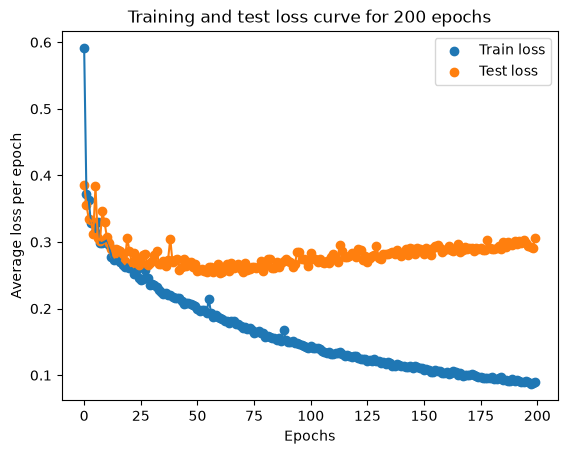

In [132]:
plt.scatter(x = np.arange(len(train_losses)), y = train_losses, label = "Train loss")
plt.scatter(x = np.arange(len(test_losses)), y = test_losses, label = "Test loss")
plt.plot(np.arange(len(train_losses)), train_losses)
plt.plot(np.arange(len(test_losses)), test_losses)

plt.xlabel("Epochs")
plt.ylabel("Average loss per epoch")
plt.title("Training and test loss curve for 200 epochs")
plt.legend()

In [134]:
class BetterWideRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(8, 512),
            nn.ReLU(),
            nn.Dropout(p = 0.5),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Dropout(p = 0.5),
            nn.Linear(1024, 1)
        )

    def forward(self, x):
        return self.layers(x)

In [135]:
model = BetterWideRegressor()
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(params = model.parameters(), lr = 1e-3, weight_decay = 1e-4)
train_losses, test_losses = trainModel(model, n_epochs = 200, optimizer = optimizer, loss_fn = loss_fn, 
                          train_data_loader = train_dataloader, test_data_loader = test_dataloader)

Epoch 1: Train loss = 0.7555
Epoch 1: Test loss = 0.4559
Epoch 2: Train loss = 0.5484
Epoch 2: Test loss = 0.4164
Epoch 3: Train loss = 0.5182
Epoch 3: Test loss = 0.4217
Epoch 4: Train loss = 0.5024
Epoch 4: Test loss = 0.3840
Epoch 5: Train loss = 0.6237
Epoch 5: Test loss = 0.3705
Epoch 6: Train loss = 0.5082
Epoch 6: Test loss = 0.3691
Epoch 7: Train loss = 0.4616
Epoch 7: Test loss = 0.3485
Epoch 8: Train loss = 0.4602
Epoch 8: Test loss = 0.3448
Epoch 9: Train loss = 0.4576
Epoch 9: Test loss = 0.3451
Epoch 10: Train loss = 0.5484
Epoch 10: Test loss = 0.3598
Epoch 11: Train loss = 0.5181
Epoch 11: Test loss = 0.3804
Epoch 12: Train loss = 0.6920
Epoch 12: Test loss = 0.3703
Epoch 13: Train loss = 0.4380
Epoch 13: Test loss = 0.3191
Epoch 14: Train loss = 0.5149
Epoch 14: Test loss = 0.3302
Epoch 15: Train loss = 0.5021
Epoch 15: Test loss = 0.3407
Epoch 16: Train loss = 0.3734
Epoch 16: Test loss = 0.3274
Epoch 17: Train loss = 0.4329
Epoch 17: Test loss = 0.3144
Epoch 18: Train

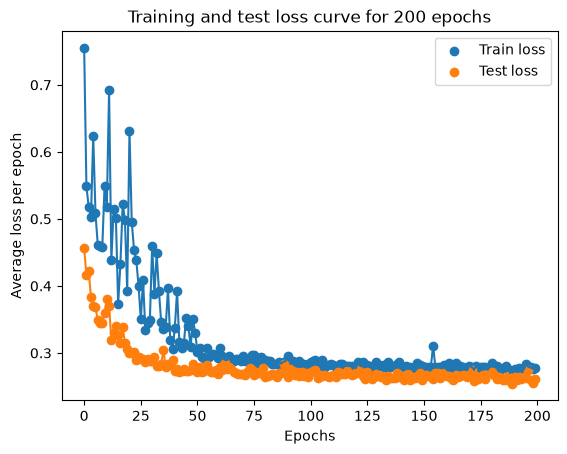

In [136]:
plt.scatter(x = np.arange(len(train_losses)), y = train_losses, label = "Train loss")
plt.scatter(x = np.arange(len(test_losses)), y = test_losses, label = "Test loss")
plt.plot(np.arange(len(train_losses)), train_losses)
plt.plot(np.arange(len(test_losses)), test_losses)

plt.xlabel("Epochs")
plt.ylabel("Average loss per epoch")
plt.title("Training and test loss curve for 200 epochs")
plt.legend()

Adding weight decay into the Adam optimizer and adding dropout layers into my model both helped to prevent 
overfitting during the training of my model. The reason is that dropout layers result in better generalization of the model, while weight decay keeps the weights from diverging. Initial instability in the training loss curve is because dropout.

### Extra credit (optional): learning-rate sweep

Train the single-hidden-layer `RegressorFFN` with several learning rates
(e.g. 1e-1, 1e-2, 1e-3, 1e-4) and plot the final **test RMSE** against the learning
rate (log scale). What happens when the learning rate is too high? Too low?

In [138]:
### YOUR CODE HERE
lr_list = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5]
test_rmse_list = []

for lr in lr_list:
    model = RegressorFFN()
    loss_fn = torch.nn.MSELoss()
    optimizer = torch.optim.Adam(params = model.parameters(), lr = lr)
    train_losses, test_losses = trainModel(model, n_epochs = 100, optimizer = optimizer, loss_fn = loss_fn, 
                              train_data_loader = train_dataloader, test_data_loader = test_dataloader)

    rmse_test, _, _ = evaluate(model, x_all_test_scaled, y_all_test)
    test_rmse_list.append(rmse_test)

Epoch 1: Train loss = 174.5347
Epoch 1: Test loss = 12.6242
Epoch 2: Train loss = 184.5120
Epoch 2: Test loss = 65.7449
Epoch 3: Train loss = 122.8924
Epoch 3: Test loss = 2.6090
Epoch 4: Train loss = 516.0249
Epoch 4: Test loss = 1.5146
Epoch 5: Train loss = 30.2235
Epoch 5: Test loss = 1.4355
Epoch 6: Train loss = 79.4948
Epoch 6: Test loss = 2.6364
Epoch 7: Train loss = 3.6353
Epoch 7: Test loss = 1.4957
Epoch 8: Train loss = 11.0374
Epoch 8: Test loss = 1.2197
Epoch 9: Train loss = 1.3778
Epoch 9: Test loss = 1.0330
Epoch 10: Train loss = 1.0869
Epoch 10: Test loss = 0.9511
Epoch 11: Train loss = 1.4262
Epoch 11: Test loss = 0.8529
Epoch 12: Train loss = 1.0741
Epoch 12: Test loss = 0.8032
Epoch 13: Train loss = 0.7778
Epoch 13: Test loss = 0.7079
Epoch 14: Train loss = 0.8893
Epoch 14: Test loss = 0.6109
Epoch 15: Train loss = 0.5828
Epoch 15: Test loss = 0.5535
Epoch 16: Train loss = 12.7802
Epoch 16: Test loss = 1.1014
Epoch 17: Train loss = 1.1665
Epoch 17: Test loss = 0.9380
E

Text(0.5, 1.0, 'Graph showing the Final test loss vs. Learning Rate')

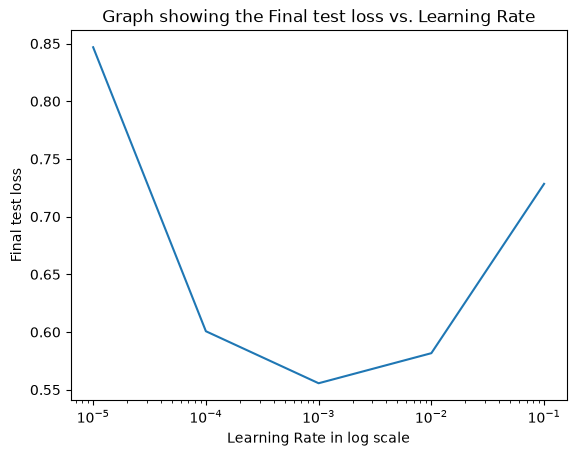

In [145]:
plt.plot(lr_list, test_rmse_list)
plt.xscale('log')
plt.xlabel("Learning Rate in log scale")
plt.ylabel("Final test loss")
plt.title("Graph showing the Final test loss vs. Learning Rate")